# cds_v4

Here, we will:
- convert featureCounts > RPKM values (Controls are infected, treatment are infected + perturbagen)
- log2 and quantile normalise RPKM values to generate Level 3 comparable data
- Convert to Level 4 data
- Convert to Level 5 data

- Apply Level 5 comparable data to graph structure
- Apply LINCS Level 5 data to graph structure
- Run GIN + contrastive learning
- Compare graphs
- Extract top n most similar graphs

# Packages

In [1]:
# General
import itertools
from itertools import combinations
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import seaborn as sns
from scipy.stats import spearmanr
from tqdm import tqdm as tqdm

# LINCS
from cmapPy.pandasGEXpress import parse

# GIN
import torch
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.utils import from_networkx
import torch.nn.functional as F
from torch.nn import Linear, Sequential, ReLU
from sklearn.metrics.pairwise import cosine_similarity

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
c:\Users\roman\AppData\Lo

# Directories

In [2]:
INPUT = 'D:/DDesktop/_work/data/canada/input/'
FEATURECOUNTS = INPUT + 'featureCounts/'
LINCS = INPUT + 'LDS-1481/'

OUTPUT = 'D:/DDesktop/_work/data/canada/output/'
FEATURECOUNTS_MERGED = OUTPUT + 'featureCounts_merged/'
CONTEXT = OUTPUT + 'context_graphs/'
RNASEQ = OUTPUT + 'rnaseq_graphs/'

# Functions

In [3]:
# GENERAL 

def file_to_list(path):
    '''
    Converts a .txt file to a list
    '''

    with open(f'{path}', 'r', encoding = 'utf-8') as f:
        list_file = [line.strip() for line in f]
    
    return list_file

def list_to_file(path, data):
      '''
      Saves a list or set to a .txt file with no header.
      '''

      with open(path, 'w') as f:
            for item in sorted(data):
                  f.write(f'{item}\n')

def pickle_load(path: str, report: bool = False):
    '''
    Loads pickled data.
    '''

    with open(path, 'rb') as f:
        data = pickle.load(f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_load')
            print(f'Pickled graph loaded w/ {num_nodes:,} nodes and {num_edges:,} edges')
            print()
        else:
            print('>> pickle_load')
            print(f'Pickled file loaded')
            print()

    return data

def pickle_save(path: str, data, report: bool = False):
    '''
    Pickles data.
    '''

    with open(path, 'wb') as f:
        pickle.dump(data, f)

    if report == True:
        if type(data) == nx.Graph:
            num_nodes = len(data.nodes)
            num_edges = len(data.edges)
            print('>> pickle_save')
            print(f'Graph w/ {num_nodes:,} nodes and {num_edges:,} edges pickled')
        else:
            print('>> pickle_save')
            print(f'Data pickled')
            print()

def quantile_normalize(df):
    """
    Perform quantile normalization on a dataframe of numeric values.
    Rows = genes, Columns = conditions.
    """
    # Convert to numpy array
    arr = df.to_numpy(dtype=float)
    
    # Sort each column
    sorted_idx = np.argsort(arr, axis=0)
    sorted_arr = np.sort(arr, axis=0)
    
    # Compute mean across rows (same rank across columns)
    mean_vals = np.mean(sorted_arr, axis=1)
    
    # Map back to original ranks
    normed = np.zeros_like(arr)
    for j in range(arr.shape[1]):
        ranks = sorted_idx[:, j]
        normed[ranks, j] = mean_vals
    
    return pd.DataFrame(normed, index=df.index, columns=df.columns)

# GIN

class GINEncoder(torch.nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=3):
        super().__init__()
        self.convs = torch.nn.ModuleList()
        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            mlp = Sequential(Linear(in_dim, hidden_dim), ReLU(), Linear(hidden_dim, hidden_dim))
            conv = GINConv(mlp)
            self.convs.append(conv)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = conv(x, edge_index)
            x = F.relu(x)
        graph_emb = global_add_pool(x, batch)  # graph-level embedding
        return graph_emb

def gin_augment_graph_batch(batch_graphs, noise_scale=0.1):
    x_aug = batch_graphs.x + noise_scale * torch.randn_like(batch_graphs.x)
    batch_aug = Batch(batch_graphs.to_data_list())
    batch_aug.x = x_aug.to(batch_graphs.x.device)
    batch_aug.edge_index = batch_graphs.edge_index
    batch_aug.batch = batch_graphs.batch
    return batch_aug

def gin_contrastive_loss(z1, z2, temperature=0.5):
    # Normalize embeddings
    z1 = F.normalize(z1, dim=1)
    z2 = F.normalize(z2, dim=1)
    
    batch_size = z1.size(0)
    
    # Cosine similarity matrix
    representations = torch.cat([z1, z2], dim=0)  # [2*B, D]
    sim_matrix = torch.matmul(representations, representations.T)  # [2B,2B]
    
    # Scale by temperature
    sim_matrix = sim_matrix / temperature
    
    # Labels: each sample i in z1 matches i+B in z2, and vice versa
    labels = torch.arange(batch_size, device=z1.device)
    
    # Mask out self-similarities
    mask = torch.eye(2*batch_size, device=z1.device).bool()
    sim_matrix.masked_fill_(mask, -9e15)  # very large negative number instead of -inf
    
    # Positive logits
    positives = torch.cat([torch.arange(batch_size, batch_size*2), torch.arange(0, batch_size)]).to(z1.device)
    
    # Cross-entropy
    loss = F.cross_entropy(sim_matrix, positives)
    return loss

def gin_extract_embeddings(encoder, list_pyg, device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    encoder.eval()
    embeddings = []
    graph_info = []
    with torch.no_grad():
        #for g in tqdm(list_pyg, desc="Generating embeddings"):
        for g in list_pyg:
            g = g.to(device)
            batch = torch.zeros(g.num_nodes, dtype=torch.long, device=device)
            z = encoder(g.x, g.edge_index, batch)
            embeddings.append(z.cpu())
            graph_info.append({'name': g.name, 'dose' : g.dose, 'timepoint': g.timepoint})
    embeddings = torch.cat(embeddings, dim=0).numpy()
    return embeddings, graph_info

def gin_preprocess(list_pyg):
    '''
    Preprocesses list of PyG graph objects to pass to GIN
    '''

    # Iterate through list
    for graph in list_pyg:

        # Check 'dexp' attribute dimensionality
        if graph.dexp.dim() == 1:
            # Convert to 2D
            graph.dexp = graph.dexp.view(-1, 1)
        
        # Convert 'dexp' to 'x'
        graph.x = graph.dexp.float()

    return list_pyg

def gin_train(list_pyg, embed_dim=64, epochs=30, batch_size=4, lr=1e-3, device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

    list_pyg = gin_preprocess(list_pyg)
    loader = DataLoader(list_pyg, batch_size=batch_size, shuffle=True)
    encoder = GINEncoder(input_dim=1, hidden_dim=embed_dim).to(device)
    optimizer = torch.optim.Adam(encoder.parameters(), lr=lr)

    #for epoch in tqdm(range(epochs), desc = f'Training contrastive GIN', total = epochs):
    for epoch in range(epochs):
        encoder.train()
        total_loss = 0
        #for batch_graphs in tqdm(loader, desc=f'Epoch {epoch+1}/{epochs}'):
        for batch_graphs in loader:
            batch_graphs = batch_graphs.to(device)
            batch_aug = gin_augment_graph_batch(batch_graphs)

            z1 = encoder(batch_graphs.x, batch_graphs.edge_index, batch_graphs.batch)
            z2 = encoder(batch_aug.x, batch_aug.edge_index, batch_aug.batch)

            loss = gin_contrastive_loss(z1, z2)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        # Report loss per epoch
        #print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

    return encoder

def gin_upper_tri(mat):
    idx = np.triu_indices_from(mat, k=1)
    
    return mat[idx]

def gin_jaccard_similarity(set1, set2):
    return len(set1 & set2) / len(set1 | set2)

# featureCounts

## Gene lengths

In [ ]:
# Get list of featureCounts files
list_featurecounts = [file for file in os.listdir(FEATURECOUNTS) if 'summary' not in file]

# Initialise dataframe
df_featurecounts = pd.DataFrame()

# Iterate through featureCounts files
for file in tqdm(list_featurecounts, desc = 'Extracting gene lengths', total = len(list_featurecounts)):
    # Load data
    df = pd.read_csv(FEATURECOUNTS + file, sep = '\t', comment = '#')
    # Extract data
    df = df[['Geneid', 'Length']]
    # Rename column
    df.rename(columns = {'Length' : file}, inplace = True)
    # Check length of df_featurecounts
    if len(df_featurecounts) > 1:
        df_featurecounts = pd.merge(df_featurecounts, df, how = 'left', on = 'Geneid')
    else:
        df_featurecounts = pd.concat([df_featurecounts, df])

# Rename column
df_featurecounts.rename(columns = {'Geneid' : 'geneid'}, inplace = True)
# Show data
df_featurecounts.head()

Extracting gene lengths: 100%|██████████| 192/192 [01:47<00:00,  1.79it/s]


,geneid,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTACCGAC-CGTATTCG_L001_featureCounts.txt,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTACCGAC-CGTATTCG_L002_featureCounts.txt,R1430-S0002_ConParo6h3_A104296_1_22WF7FLT3_TCGTCTGA-TCAAGGAC_L001_featureCounts.txt,R1430-S0002_ConParo6h3_A104296_1_22WF7FLT3_TCGTCTGA-TCAAGGAC_L002_featureCounts.txt,R1430-S0003_ConParo24h1_A104297_1_22WF7FLT3_TTCCAGGT-AAGCACTG_L001_featureCounts.txt,R1430-S0003_ConParo24h1_A104297_1_22WF7FLT3_TTCCAGGT-AAGCACTG_L002_featureCounts.txt,R1430-S0004_ConNita6h2_A104298_1_22WF7FLT3_TACGGTCT-GCAATGGA_L001_featureCounts.txt,R1430-S0004_ConNita6h2_A104298_1_22WF7FLT3_TACGGTCT-GCAATGGA_L002_featureCounts.txt,R1430-S0005_conNita24h2_A104299_1_22WF7FLT3_AAGACCGT-CAATCGAC_L001_featureCounts.txt,...,R1430-S0092_96h2_A108028_1_22WF7FLT3_CTTGACGA-TTGTGTGC_L001_featureCounts.txt,R1430-S0092_96h2_A108028_1_22WF7FLT3_CTTGACGA-TTGTGTGC_L002_featureCounts.txt,R1430-S0093_96h3_A108029_1_22WF7FLT3_GCCACGAC-ACCCGAGG_L001_featureCounts.txt,R1430-S0093_96h3_A108029_1_22WF7FLT3_GCCACGAC-ACCCGAGG_L002_featureCounts.txt,R1430-S0094_120h2_A108030_1_22WF7FLT3_TCTGGAAC-AGGTGCTA_L001_featureCounts.txt,R1430-S0094_120h2_A108030_1_22WF7FLT3_TCTGGAAC-AGGTGCTA_L002_featureCounts.txt,R1430-S0095_144h1_A108031_1_22WF7FLT3_CACTAGAC-AGTCCTCA_L001_featureCounts.txt,R1430-S0095_144h1_A108031_1_22WF7FLT3_CACTAGAC-AGTCCTCA_L002_featureCounts.txt,R1430-S0096_168h3_A108032_1_22WF7FLT3_TTGCGTTA-TTCGGGAA_L001_featureCounts.txt,R1430-S0096_168h3_A108032_1_22WF7FLT3_TTGCGTTA-TTCGGGAA_L002_featureCounts.txt
0,DDX11L1,1652,1652,1652,1652,1652,1652,1652,1652,1652,...,1652,1652,1652,1652,1652,1652,1652,1652,1652,1652
1,WASH7P,1769,1769,1769,1769,1769,1769,1769,1769,1769,...,1769,1769,1769,1769,1769,1769,1769,1769,1769,1769
2,MIR6859-1,68,68,68,68,68,68,68,68,68,...,68,68,68,68,68,68,68,68,68,68
3,MIR1302-2HG,2263,2263,2263,2263,2263,2263,2263,2263,2263,...,2263,2263,2263,2263,2263,2263,2263,2263,2263,2263
4,MIR1302-2,138,138,138,138,138,138,138,138,138,...,138,138,138,138,138,138,138,138,138,138


In [51]:
# Melt data
df_featurecounts_melt = pd.melt(df_featurecounts, id_vars = 'geneid')
# Show data
df_featurecounts_melt.head()

,geneid,variable,value
0,DDX11L1,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,1652
1,WASH7P,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,1769
2,MIR6859-1,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,68
3,MIR1302-2HG,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,2263
4,MIR1302-2,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,138


In [52]:
# Copy data
df_featurecounts_drop = df_featurecounts_melt.copy()
# Drop duplicates based on Geneid and value
df_featurecounts_drop.drop_duplicates(subset = ['geneid', 'value'], inplace = True)
# Show data
df_featurecounts_drop.head()

,geneid,variable,value
0,DDX11L1,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,1652
1,WASH7P,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,1769
2,MIR6859-1,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,68
3,MIR1302-2HG,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,2263
4,MIR1302-2,R1430-S0001_ConParo6h1_A104295_1_22WF7FLT3_TTA...,138


In [53]:
# Group data to check for number of unique length values/gene
df_featurecounts_group = df_featurecounts_drop[['geneid', 'value']].groupby(by = 'geneid').count()
# Check for values > 1
df_slice = df_featurecounts_group[df_featurecounts_group['value'] > 1]
num_genes = len(df_slice)
print(f'{num_genes:,} genes found with multiple length values')
# Show data
df_featurecounts_group.head()

0 genes found with multiple length values


,value
geneid,
A1BG,1
A1BG-AS1,1
A1CF,1
A2M,1
A2M-AS1,1


In [60]:
# Extract count data
df_lengths = df_featurecounts_drop[['geneid', 'value']].copy()
# Rename column
df_lengths.rename(columns = {'value' : 'length'}, inplace = True)
# Save data
pickle_save(OUTPUT + 'df_lengths.pkl', df_lengths)
# Show data
df_lengths.head()

,geneid,length
0,DDX11L1,1652
1,WASH7P,1769
2,MIR6859-1,68
3,MIR1302-2HG,2263
4,MIR1302-2,138


# RPKM

## Combine lane files

In [55]:
# Get list of featureCounts files
list_featurecounts = [file for file in os.listdir(FEATURECOUNTS) if 'summary' not in file]
# Get list of unique samples
list_samples = list(set([file.split('_L00')[0] for file in list_featurecounts]))
# Get number of unique samples
num_samples = len(list_samples)
# Report
print(f'{num_samples:,} unique samples found in featureCounts files')
print()



# Iterate through files
for sample in tqdm(list_samples, desc = 'Merging lane files', total = num_samples):

    # Get description
    desc = sample.split('_')[1]
    replicate = desc[-1]
    desc = desc[:-1]

    # Load lane files
    df1 = pd.read_csv(FEATURECOUNTS + f'{sample}_L001_featureCounts.txt', sep = '\t', comment = '#')
    df2 = pd.read_csv(FEATURECOUNTS + f'{sample}_L002_featureCounts.txt', sep = '\t', comment = '#')

    # Extract Geneid and count columns
    df1 = df1.iloc[:, [0, -1]]
    df2 = df2.iloc[:, [0, -1]]

    # Rename columns
    df1.rename(columns = {df1.columns[1] : 'lane1'}, inplace = True)
    df2.rename(columns = {df2.columns[1] : 'lane2'}, inplace = True)

    # Merge data
    df = pd.merge(df1, df2, how = 'left', on = 'Geneid')

    # Generate sum column
    df['count'] = df['lane1'] + df['lane2']
    # Extract data
    df = df[['Geneid', 'count']]
    # Rename columns
    df.rename(columns = {'Geneid' : 'geneid'}, inplace = True)

    # Save data
    pickle_save(FEATURECOUNTS_MERGED + f'{desc}_{replicate}.pkl', df)

# Show example data
df.head()

96 unique samples found in featureCounts files



Merging lane files: 100%|██████████| 96/96 [01:43<00:00,  1.08s/it]


,geneid,count
0,DDX11L1,0
1,WASH7P,250
2,MIR6859-1,2
3,MIR1302-2HG,0
4,MIR1302-2,0


## Calculate RPKM values

In [9]:
# Load gene length data
df_lengths = pickle_load(OUTPUT + 'df_lengths.pkl')

# Define timepoint list
list_timepoints = ['6h', '24h']

# Iterate through timepoints
for timepoint in list_timepoints:

    # Get control file list (infected + vehicle controls)
    # list_control = [file for file in os.listdir(FEATURECOUNTS_MERGED) if f'Ve{timepoint}' in file]
    # Get control file list (uninfected controls)
    list_control = [file for file in os.listdir(FEATURECOUNTS_MERGED) if 'UI' in file]
    # Get treatment file list (infected + treatment)
    # list_treatment = [file for file in os.listdir(FEATURECOUNTS_MERGED) if 
    #                   'Con' not in file and 
    #                   'Colo' not in file and 
    #                   '96h_' not in file and
    #                   'Ve' not in file and
    #                   'Positive' not in file and
    #                   timepoint in file]
    # Get treatment file list (treatment only)
    list_treatment = [file for file in os.listdir(FEATURECOUNTS_MERGED) if
                      'Con' not in file and
                      '96h_' not in file and
                      'Ve' not in file and
                      'Positive' not in file and
                      'Colo' in file and
                      timepoint in file]

    # Combine for file list
    list_files = list_control + list_treatment

    # Initialise dataframe
    df_timepoint = pd.DataFrame()

    # Iterate through list_files
    for file in list_files:

        # Get description
        desc = file.split('.')[0]
        # treatment = desc.split(timepoint)[0]
        # replicate = desc.split('_')[1]
        # column_name = treatment + '_' + timepoint + replicate

        # Load data
        df = pickle_load(FEATURECOUNTS_MERGED + file)
        # Rename column
        df.rename(columns = {'count' : desc}, inplace = True)

        # Merge data
        if len(df_timepoint) > 0:
            df_timepoint = pd.merge(df_timepoint, df, how = 'left', on = 'geneid')
        else:
            df_timepoint = pd.concat([df_timepoint, df])
    
    # Merge with length data
    df_timepoint = pd.merge(df_timepoint, df_lengths, how = 'left', on = 'geneid')

    # Convert length data to kilobases
    df_timepoint['length_kb'] = df_timepoint['length'] / 1000
    # Get gene lengths in kilobases
    list_kb = df_timepoint['length_kb'].values

    # Define count columns
    list_columns = [column for column in df_timepoint.columns[1:-2]]
    # Calculate library sizes (total mapped reads per sample)
    library_sizes = df_timepoint[list_columns].sum(axis = 0)
    # Compute RPKM
    df_rpkm = df_timepoint[list_columns].div(list_kb, axis = 0).div(library_sizes / 1e6, axis = 1)
    # Insert geneids
    df_rpkm.insert(0, 'geneid', df_timepoint['geneid'])

    # Save data
    pickle_save(OUTPUT + f'{timepoint}_rpkm.pkl', df_rpkm)

# Show example data
df_rpkm.head()

,geneid,UI_1,UI_2,UI_3,ColoHalo24h_1,ColoHalo24h_2,ColoHalo24h_3,ColoNita24h_1,ColoNita24h_2,ColoNita24h_3,ColoParo24h_1,ColoParo24h_2,ColoParo24h_3
0,DDX11L1,0.000000,0.000000,0.000000,0.028460,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,WASH7P,7.306364,5.610392,6.404163,21.155505,17.853747,23.035899,6.237010,4.831299,5.968643,6.873859,6.139020,4.356059
2,MIR6859-1,4.936958,2.753825,3.716039,2.074199,2.101629,0.667341,0.544476,0.604254,4.436357,1.943711,0.725931,1.596079
3,MIR1302-2HG,0.000000,0.000000,0.000000,0.020776,0.021050,0.020053,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,MIR1302-2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Normalisation

## Log2 Transform

In [10]:
# Define timepoint list
list_timepoints = ['6h', '24h']

# Iterate through timepoints
for timepoint in list_timepoints:

    # Load data
    df_log2 = pickle_load(OUTPUT + f'{timepoint}_rpkm.pkl')
    # Set index
    df_log2.set_index('geneid', inplace = True)
    # Log2 transform
    df_log2 = np.log2(df_log2 + 1)
    # Reset index
    df_log2.reset_index(inplace = True)
    # Save data
    pickle_save(OUTPUT + f'{timepoint}_log2.pkl', df_log2)

# Show example data
df_log2.head()

,geneid,UI_1,UI_2,UI_3,ColoHalo24h_1,ColoHalo24h_2,ColoHalo24h_3,ColoNita24h_1,ColoNita24h_2,ColoNita24h_3,ColoParo24h_1,ColoParo24h_2,ColoParo24h_3
0,DDX11L1,0.000000,0.000000,0.000000,0.040485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,WASH7P,3.054217,2.724736,2.888337,4.469593,4.236779,4.587119,2.855394,2.543817,2.800878,2.977071,2.835726,2.421172
2,MIR6859-1,2.569724,1.908361,2.237576,1.620211,1.633026,0.737549,0.627118,0.681903,2.442640,1.557636,0.787375,1.376334
3,MIR1302-2HG,0.000000,0.000000,0.000000,0.029666,0.030054,0.028644,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,MIR1302-2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Quantile Normalisation

In [11]:
# Define timepoint list
list_timepoints = ['6h', '24h']

# Iterate through timepoints
for timepoint in list_timepoints:

    # Load data
    df_qn = pickle_load(OUTPUT + f'{timepoint}_log2.pkl')
    # Set index
    df_qn.set_index('geneid', inplace = True)
    # Apply quantile normalisation
    df_qn = quantile_normalize(df_qn)
    # Reset index
    df_qn.reset_index(inplace = True)
    # Save data
    pickle_save(OUTPUT + f'{timepoint}_quantile.pkl', df_qn)

# Show example data
df_qn.head()

,geneid,UI_1,UI_2,UI_3,ColoHalo24h_1,ColoHalo24h_2,ColoHalo24h_3,ColoNita24h_1,ColoNita24h_2,ColoNita24h_3,ColoParo24h_1,ColoParo24h_2,ColoParo24h_3
0,DDX11L1,0.000000,0.000000,0.000000,0.021541,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,WASH7P,3.002574,2.542252,2.773027,4.539240,4.304878,4.664678,2.897604,2.674655,2.788037,2.966241,2.802069,2.441355
2,MIR6859-1,2.490847,1.720230,2.111409,1.721874,1.723513,0.746108,0.661919,0.754960,2.423780,1.528036,0.779611,1.394965
3,MIR1302-2HG,0.000000,0.000000,0.000000,0.009567,0.013120,0.007484,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,MIR1302-2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


# Landmark genes

In [12]:
# Load graph_cds
graph_cds = pickle_load(INPUT + 'graph_cds.pkl')
# Get nodelist
list_lm = list(graph_cds.nodes)

In [13]:
# Define timepoint list
list_timepoints = ['6h', '24h']

# Iterate through timepoints
for timepoint in list_timepoints:

    # Load quantile normalised data
    df = pickle_load(OUTPUT + f'{timepoint}_quantile.pkl')
    # Filter by landmark genes
    df = df[df['geneid'].isin(list_lm)]
    # Save data
    pickle_save(OUTPUT + f'{timepoint}_l3.pkl', df)

# Show example data
df.head()

,geneid,UI_1,UI_2,UI_3,ColoHalo24h_1,ColoHalo24h_2,ColoHalo24h_3,ColoNita24h_1,ColoNita24h_2,ColoNita24h_3,ColoParo24h_1,ColoParo24h_2,ColoParo24h_3
173,DFFB,1.252895,1.187457,1.365609,0.109777,0.097430,0.282157,1.169030,1.001166,1.163409,1.243539,1.191530,1.272785
202,ICMT,5.180911,5.105615,5.242202,2.980218,3.106388,3.034766,5.081794,4.682233,5.322390,5.119247,5.300834,5.321425
216,KLHL21,3.882647,4.125080,4.208418,5.429854,5.458885,5.220906,3.911419,3.809688,3.969790,3.634647,3.983427,3.955676
274,CLSTN1,5.234368,5.405949,5.421870,5.040245,5.035693,5.073097,5.448521,5.021794,5.602651,5.305480,5.611156,5.509815
291,DFFA,3.979676,3.790085,3.952899,2.988374,2.689942,3.004103,4.162032,3.876463,4.265723,4.332648,4.148701,4.211774


# Level 4

In [15]:
# Define timepoint list
list_timepoints = ['6h', '24h']

# Iterate through timepoints
for timepoint in list_timepoints:

    # Load data
    df_l4 = pickle_load(OUTPUT + f'{timepoint}_l3.pkl')
    # Set index
    df_l4.set_index('geneid', inplace = True)
    
    # Define control columns
    list_controls = [column for column in df_l4.columns if 'UI' in column]
    # Define treatment columns
    list_treatment = [column for column in df_l4.columns[3:]]

    # Calculate median of controls
    control_median = df_l4[list_controls].median(axis = 1)
    # Calculate MAD per gene
    control_mad = (df_l4[list_controls].sub(control_median, axis = 0).abs().median(axis = 1))
    # Calculate absolute deviations from the control median per gene and replicate
    absdev = df_l4[list_controls].sub(control_median, axis = 0).abs()
    # Aggregate to a global floor (genes and control replicates)
    mad_floor = absdev.median().median()
    # Replace too-small per-gene MAD with minimum value
    effective_mad = control_mad.clip(lower = mad_floor)

    # Calculate Level 4 Z-scores
    for column in list_treatment:
        df_l4[column + '_L4'] = (df_l4[column] - control_median) / (1.4826 * effective_mad)
    
    # Extract relevant data
    df_l4 = df_l4[[column for column in df_l4 if '_L4' in column]]
    # Reset index
    df_l4.reset_index(inplace = True)
    # Save data
    pickle_save(OUTPUT + f'{timepoint}_l4.pkl', df_l4)

# Show example data
df_l4.head()

,geneid,ColoHalo24h_1_L4,ColoHalo24h_2_L4,ColoHalo24h_3_L4,ColoNita24h_1_L4,ColoNita24h_2_L4,ColoNita24h_3_L4,ColoParo24h_1_L4,ColoParo24h_2_L4,ColoParo24h_3_L4
0,DFFB,-11.782384,-11.909645,-10.005624,-0.864425,-2.594628,-0.922362,-0.096435,-0.632511,0.205004
1,ICMT,-24.217940,-22.829484,-23.617659,-1.090745,-5.487797,1.556934,-0.678588,1.319713,1.546318
2,KLHL21,10.560145,10.795111,8.869033,-1.729259,-2.552616,-1.256835,-3.969309,-1.146470,-1.371070
3,CLSTN1,-6.564929,-6.646643,-5.975175,0.764241,-6.896155,3.531110,-1.803559,3.683777,1.864557
4,DFFA,-17.314653,-22.671962,-17.032305,3.754248,-1.372137,5.615657,6.817058,3.514937,4.647187


# Level 5

In [16]:
# Define timepoint list
list_timepoints = ['6h', '24h']
# Define treatment list
list_treatments = ['Halo', 'Nita', 'Paro']

# Iterate through timepoints
for timepoint in list_timepoints:

    # Load data
    df = pickle_load(OUTPUT + f'{timepoint}_l4.pkl')
    # Set index
    df.set_index('geneid', inplace = True)

    # Initialise dataframe
    df_l5 = pd.DataFrame()
    
    # Iterate through treatments
    for treatment in list_treatments:

        # Get data
        df_treatment = df[[column for column in df.columns if treatment in column]]
        # Extract values
        Z = df_treatment.values
        # Compute pairwise Spearman correlation between replicates
        corr_matrix, _ = spearmanr(Z, axis = 0)
        # Extract replicate x replicate values
        R = df_treatment.shape[1]
        corr_matrix = corr_matrix[:R, :R]
        # Zero self-correlations
        np.fill_diagonal(corr_matrix, 0)
        # Compute weights as sum of correlations for each replicate
        weights = corr_matrix.sum(axis = 0)
        # Normalise weights to sum to 1
        weights = weights / weights.sum()
        # Compute MODZ as weighted average of replicate vectors
        modz = np.dot(Z, weights)
        # Check results
        results = pd.Series(modz, index = df_treatment.index, name = 'modz')
        # Convert to dataframe
        df_results = pd.DataFrame({treatment : results})
        # Reset index
        df_results.reset_index(inplace = True)

        # Merge w/ df_l5
        if len(df_l5) > 1:
            df_l5 = pd.merge(df_l5, df_results, how = 'left', on = 'geneid')
        else:
            df_l5 = pd.concat([df_l5, df_results])
    
    # Save data
    pickle_save(OUTPUT + f'{timepoint}_l5.pkl', df_l5)

# Show example data
df_l5.head()

,geneid,Halo,Nita,Paro
0,DFFB,-11.229916,-1.377410,-0.188791
1,ICMT,-23.555458,-1.564780,0.894234
2,KLHL21,10.072150,-1.824957,-1.947356
3,CLSTN1,-6.394672,-0.609519,1.619660
4,DFFA,-19.000965,2.837829,4.770820


# RNAseq Graphs

In [17]:
# Load graph_cds
graph_cds = pickle_load(INPUT + 'graph_cds.pkl')
# Define timepoint list
list_timepoints = ['6h', '24h']
# Define treatment list
list_treatment = ['Halo', 'Nita', 'Paro']
# Define dose list
list_doses = ['20.85', '15.4', '9.72']

# Iterate through timepoints
for timepoint in tqdm(list_timepoints, desc = 'Generating timepoint RNAseq graphs', total = 2):

    # Load level 5 data
    df = pickle_load(OUTPUT + f'{timepoint}_l5.pkl')
    # Set index
    df.set_index('geneid', inplace = True)
    # Iterate through columns
    for treatment, dose in zip(list_treatment, list_doses):

        # Slice dataframe
        df_slice = df[[treatment]]
        # Copy CDS graph
        graph_slice = graph_cds.copy()
        # Set node attributes
        nx.set_node_attributes(graph_slice, df_slice[treatment].to_dict(), name = 'dexp')
        # Save graph
        pickle_save(RNASEQ + f'COLO680_{treatment}_{dose}_{timepoint}.pkl', graph_slice)

Generating timepoint RNAseq graphs: 100%|██████████| 2/2 [00:00<00:00, 15.94it/s]


# LINCS Data

## Signature Info

In [4]:
# Load data
df_signature_info = pd.read_csv(LINCS + 'GSE92742_Broad_LINCS_sig_info.txt.gz', compression = 'gzip', sep = '\t')
# Rename columns
df_signature_info.rename(columns = {'pert_id' : 'perturbagen_id', 'pert_iname' : 'perturbagen_name'}, inplace = True)
# Save data
pickle_save(OUTPUT + 'df_signature_info.pkl', df_signature_info)
# Show data
df_signature_info.head()

C:\Users\roman\AppData\Local\Temp\ipykernel_28024\3461196121.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_signature_info = pd.read_csv(LINCS + 'GSE92742_Broad_LINCS_sig_info.txt.gz', compression = 'gzip', sep = '\t')


,sig_id,perturbagen_id,perturbagen_name,pert_type,cell_id,pert_dose,pert_dose_unit,pert_idose,pert_time,pert_time_unit,pert_itime,distil_id
0,AML001_CD34_24H:A05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:A05
1,AML001_CD34_24H:A06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:A06
2,AML001_CD34_24H:B05,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X1_F1B10:B05|AML001_CD34_24H_X...
3,AML001_CD34_24H:B06,DMSO,DMSO,ctl_vehicle,CD34,0.1,%,0.1 %,24,h,24 h,AML001_CD34_24H_X3_F1B10:B06
4,AML001_CD34_24H:BRD-A03772856:0.37037,BRD-A03772856,BRD-A03772856,trt_cp,CD34,0.37037,µM,500 nM,24,h,24 h,AML001_CD34_24H_X1_F1B10:J04|AML001_CD34_24H_X...


## Perturbagen Info

In [5]:
# Load data
df_perturbagen_info = pickle_load(OUTPUT + 'df_signature_info.pkl')
# Extract relevant data
df_perturbagen_info = df_perturbagen_info[['perturbagen_id', 'perturbagen_name']].copy()
# Remove duplicates
df_perturbagen_info.drop_duplicates(inplace = True, ignore_index = True)
# Save data
pickle_save(OUTPUT + 'df_perturbagen_info.pkl', df_perturbagen_info)
# Show data
df_perturbagen_info.head()

,perturbagen_id,perturbagen_name
0,DMSO,DMSO
1,BRD-A03772856,BRD-A03772856
2,BRD-A19037878,trichostatin-a
3,BRD-A19500257,geldanamycin
4,BRD-A34037822,KUC107191N


## Gene Info

In [6]:
# Load data
df_gene_info = pd.read_csv(LINCS + 'GSE92742_Broad_LINCS_gene_info.txt.gz', compression = 'gzip', sep = '\t')

# Rename columns
old_names = ['pr_gene_id', 'pr_gene_symbol', 'pr_gene_title', 'pr_is_lm', 'pr_is_bing']
new_names = ['rid', 'lincs_name', 'lincs_desc', 'landmark', 'inferred']

for old, new in zip(old_names, new_names):
    df_gene_info.rename(columns = {old : new}, inplace = True)

# Save data
pickle_save(OUTPUT + 'df_gene_info.pkl', df_gene_info)
# Show data
df_gene_info.head()

,rid,lincs_name,lincs_desc,landmark,inferred
0,780,DDR1,discoidin domain receptor tyrosine kinase 1,1,1
1,7849,PAX8,paired box 8,1,1
2,2978,GUCA1A,guanylate cyclase activator 1A,0,0
3,2049,EPHB3,EPH receptor B3,0,1
4,2101,ESRRA,estrogen related receptor alpha,0,1


## Landmark Info

In [7]:
# Load data
df_landmark_info = pickle_load(OUTPUT + 'df_gene_info.pkl')
# Filter data
df_landmark_info = df_landmark_info[df_landmark_info['landmark'] == 1]
# Drop columns
df_landmark_info.drop(columns = ['landmark', 'inferred'], inplace = True)
# Save data
pickle_save(OUTPUT + 'df_landmark_info.pkl', df_landmark_info)
# Show data
df_landmark_info.head()

,rid,lincs_name,lincs_desc
0,780,DDR1,discoidin domain receptor tyrosine kinase 1
1,7849,PAX8,paired box 8
25,6193,RPS5,ribosomal protein S5
43,23,ABCF1,ATP binding cassette subfamily F member 1
49,9552,SPAG7,sperm associated antigen 7


## Signature Filter

In [8]:
# Filters
FILTER_CELLS = ['HT29']
FILTER_TIMEPOINTS = [6]
FILTER_DOSES = [10]

In [9]:
# Load data
df_signature_info = pickle_load(OUTPUT + 'df_signature_info.pkl')
# Filter data
df_filter = df_signature_info[(df_signature_info['cell_id'].isin(FILTER_CELLS)) &
                              (df_signature_info['pert_time'].isin(FILTER_TIMEPOINTS)) &
                              (df_signature_info['pert_dose'].isin(FILTER_DOSES))]

# Report
print(f'Cell(s): {FILTER_CELLS}')
print(f'Timepoint(s): {FILTER_TIMEPOINTS}')
print(f'Dose(s): {FILTER_DOSES}')
print()
num_perturbagens = len(pd.unique(df_filter['perturbagen_id']))
print(f'{num_perturbagens:,} unique perturbagens found after filtering')

# Extract signature IDs
list_signatures = list(pd.unique(df_filter['sig_id']))
# Save data
list_to_file(OUTPUT + 'list_signatures.txt', list_signatures)

Cell(s): ['HT29']
Timepoint(s): [6]
Dose(s): [10]

5,045 unique perturbagens found after filtering


## Signature Values

In [10]:
# Load data
list_signatures = file_to_list(OUTPUT + 'list_signatures.txt')
df_gene_info = pickle_load(OUTPUT + 'df_gene_info.pkl')
df_perturbagen_info = pickle_load(OUTPUT + 'df_perturbagen_info.pkl')

In [11]:
# Filter lincs data
df_lincs = parse.parse(LINCS + 'LDS-1481_1.0.gctx', cid = list_signatures).data_df
# Extract column IDs for signature metadata
list_column_ids = list(df_lincs.columns)
# Show data
df_lincs.head()

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\cmapPy\pandasGEXpress\parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


cid,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005_HT29_6H:BRD-A07824748-001-02-6:10,CPC004_HT29_6H:BRD-K20482099-001-01-1:10,CPC005_HT29_6H:BRD-K62929068-001-03-3:10,CPC005_HT29_6H:BRD-K43405658-001-01-8:10,CPC004_HT29_6H:BRD-K03670461-001-02-0:10,CPC004_HT29_6H:BRD-K36737713-001-01-6:10,CPC005_HT29_6H:BRD-K51223576-001-01-3:10,CPC004_HT29_6H:BRD-A14966924-001-03-0:10,CPC004_HT29_6H:BRD-K79131256-001-08-8:10,...,PCLB001_HT29_6H:BRD-K45028728-001-02-0:10,PCLB001_HT29_6H:BRD-A15100685-001-02-6:10,PCLB001_HT29_6H:BRD-A33746814-001-01-0:10,PCLB001_HT29_6H:BRD-K07572174-001-22-0:10,PCLB001_HT29_6H:BRD-A70150975-001-01-4:10,PCLB001_HT29_6H:BRD-A69592287-001-01-3:10,PCLB001_HT29_6H:BRD-A58955223-001-02-0:10,PCLB001_HT29_6H:BRD-K36452089-001-01-8:10,PCLB001_HT29_6H:BRD-A34462049-001-04-4:10,PCLB001_HT29_6H:BRD-A19037878-001-02-3:10
rid,,,,,,,,,,,,,,,,,,,,,
5720,-2.999525,-0.623000,0.141888,-0.752267,0.380861,0.076565,-0.749507,-0.284185,0.664252,-0.007322,...,-0.227952,1.056974,-1.633453,-0.368609,-0.941537,-2.133886,0.196782,0.700733,-0.349926,-0.032394
466,-1.922989,-1.483600,-0.004969,-1.476633,0.828392,0.913175,-0.654432,0.067755,0.684563,1.565995,...,-0.956585,0.259887,-2.375699,-0.220565,-1.854915,-1.416142,0.007847,0.721920,0.123217,-3.753825
6009,-0.742801,-0.406733,-0.614206,-3.505600,0.381193,0.356511,-0.324873,-0.300248,0.563278,1.232050,...,0.776871,-0.175295,-2.321007,-0.337826,-0.622213,-1.499496,0.309883,-0.555653,0.591362,-1.339114
2309,-1.567428,0.373000,0.258819,0.750733,-0.013309,-0.172938,-0.571196,0.091755,0.042603,-1.011316,...,-0.087529,-0.548147,-1.061960,1.320128,-0.104126,-0.584865,1.146974,-0.014965,2.970267,-0.826604
387,-2.488176,-0.959167,0.737944,-1.150100,-0.292709,-1.357093,0.885794,-0.627101,-0.029998,-0.127312,...,-0.123872,0.310397,-1.934787,-0.110689,-0.655762,-1.680875,0.470595,0.158953,-0.369358,0.116622


### Signature Metadata

In [12]:
# Extract df_lincs columns IDs
df_metadata = pd.DataFrame(list_column_ids, columns = ['cid'])
# Copy column
df_metadata['metadata'] = df_metadata['cid']
# Extract perturbagen ID
df_metadata['metadata'] = df_metadata['metadata'].str.replace(r'-(?:[^-]+-){2}[^-]+(?=:\d+$)', '', regex = True)
# Split metadata column
df_metadata[['data', 'perturbagen_id', 'dose']] = df_metadata['metadata'].str.split(':', expand = True)
# Split data column
df_metadata[['dataset', 'cell_line', 'timepoint']] = df_metadata['data'].str.split('_', expand = True)
# Drop columns
df_metadata.drop(columns = ['metadata', 'data'], inplace = True)

# Merge with perturbagen data
df_metadata = pd.merge(df_metadata, df_perturbagen_info, how = 'left', on  = 'perturbagen_id')
# Show data
df_metadata.head()

,cid,perturbagen_id,dose,dataset,cell_line,timepoint,perturbagen_name
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,BRD-A85280935,10,CPC005,HT29,6H,quinpirole
1,CPC005_HT29_6H:BRD-A07824748-001-02-6:10,BRD-A07824748,10,CPC005,HT29,6H,flavanone
2,CPC004_HT29_6H:BRD-K20482099-001-01-1:10,BRD-K20482099,10,CPC004,HT29,6H,rutin
3,CPC005_HT29_6H:BRD-K62929068-001-03-3:10,BRD-K62929068,10,CPC005,HT29,6H,6-benzylaminopurine
4,CPC005_HT29_6H:BRD-K43405658-001-01-8:10,BRD-K43405658,10,CPC005,HT29,6H,tyrphostin-AG-527


### Signature Values

In [13]:
# Reset index
df_lincs.reset_index(inplace = True)
# Assert datatypes
df_lincs['rid'] = df_lincs['rid'].astype(int)
df_gene_info['rid'] = df_gene_info['rid'].astype(int)

# Merge data
df_lincs = pd.merge(df_lincs, df_gene_info[['rid', 'lincs_name', 'lincs_desc', 'landmark']], how = 'left', on = 'rid')
# Melt on expression values
df_lincs = df_lincs.melt(id_vars = ['rid', 'lincs_name', 'lincs_desc', 'landmark'], var_name = 'cid', value_name = 'value')

# Merge w/ df_metadata
df_lincs = pd.merge(df_lincs, df_metadata, how = 'left', on = 'cid')
# Reorder columns
list_columns = ['cid', 'dataset', 'cell_line', 'perturbagen_id', 'perturbagen_name', 'dose', 'timepoint', 'rid', 'lincs_name', 'lincs_desc', 'landmark', 'value']
df_lincs = df_lincs[list_columns]
# Rename columns
df_lincs.rename(columns = {'rid' : 'gene_id', 'value' : 'dexp'}, inplace = True)

# Save data
pickle_save(OUTPUT + 'df_lincs.pkl', df_lincs)
pickle_save(OUTPUT + 'df_metadata.pkl', df_metadata)

# Show data
df_lincs.head()

,cid,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,lincs_name,lincs_desc,landmark,dexp
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,5720,PSME1,proteasome activator subunit 1,1,-2.999525
1,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,466,ATF1,activating transcription factor 1,1,-1.922989
2,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,6009,RHEB,Ras homolog enriched in brain,1,-0.742801
3,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,2309,FOXO3,forkhead box O3,1,-1.567428
4,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,387,RHOA,ras homolog family member A,1,-2.488176


# Context Graphs

In [14]:
# Load landmark graph
graph_cds = pickle_load(INPUT + 'graph_cds.pkl')
# Load data
df_lincs = pickle_load(OUTPUT + 'df_lincs.pkl')

## Perturbagens

In [15]:
# Load perturbagens
df_perturbagens = df_lincs[['perturbagen_id', 'perturbagen_name']].copy()
# Remove duplicates
df_perturbagens.drop_duplicates(inplace = True)
# Show data
df_perturbagens.head()

,perturbagen_id,perturbagen_name
0,BRD-A85280935,quinpirole
12328,BRD-A07824748,flavanone
24656,BRD-K20482099,rutin
36984,BRD-K62929068,6-benzylaminopurine
49312,BRD-K43405658,tyrphostin-AG-527


In [84]:
print(len(df_perturbagens))

5045


### Randomly Selected

In [90]:
# Define number of random perturbagens
N_PERTURBAGENS = 5045

# Copy data
df_sample = df_perturbagens.copy()
# Sample random perturbagens
df_sample = df_sample.sample(n = N_PERTURBAGENS)
# Show data
df_sample.head()

,perturbagen_id,perturbagen_name
9862400,BRD-K02822062,CT-200783
31251480,BRD-K48823327,BRD-K48823327
28083184,BRD-K71879957,BRD-K71879957
48498352,BRD-K97863768,prothionamide
10182928,BRD-A58955223,sulforaphane


In [91]:
print(len(df_sample))

5045


### Manually Selected

In [92]:
# # Initialise dataframe
df_selected = pd.DataFrame()

# # Get statins
df_statin = df_perturbagens[df_perturbagens['perturbagen_name'].str.contains('statin')]
num_statin = len(pd.unique(df_statin['perturbagen_id']))
# Report
print(f'{num_statin:,} -statin compounds found')

# Define profen drug list
list_profen = ['ibuprofen', 'indoprofen']
num_profen = len(list_profen)
# Get profen data
df_profen = df_perturbagens[df_perturbagens['perturbagen_name'].isin(list_profen)]
num_profen_found = len(pd.unique(df_profen['perturbagen_id']))
percent_profen = num_profen_found / num_profen * 100
print(f'{percent_profen:.2f}% of -profen compounds found in data ({num_profen_found:,}/{num_profen:,})')

# Load hdac data
list_hdac = file_to_list(INPUT + 'list_hdac.txt')
# Format
list_hdac = [entry.lower() for entry in list_hdac]
num_hdac = len(list_hdac)
# Get hdac data
df_hdac = df_perturbagens[df_perturbagens['perturbagen_name'].isin(list_hdac)]
num_hdac_found = len(pd.unique(df_hdac['perturbagen_id']))
percent_hdac = num_hdac_found / num_hdac * 100
print(f'{percent_hdac:.2f}% of hdac compounds found in data ({num_hdac_found:,}/{num_hdac:,})')

# Load opioid data
list_opioid = file_to_list(INPUT + 'list_opioids.txt')
# Format
list_opioid = [entry.lower() for entry in list_opioid]
num_op = len(list_opioid)
df_op = df_perturbagens[df_perturbagens['perturbagen_name'].isin(list_opioid)]
num_op_found = len(pd.unique(df_op['perturbagen_id']))
percent_op = num_op_found / num_op * 100
print(f'{percent_op:.2f}% of opioid compounds found in data ({num_op_found:,}/{num_op:,})')

# Concatenate data
for df in [df_statin, df_profen, df_hdac, df_op]:
    df_selected = pd.concat([df_selected, df])

# Show data
df_selected.head()

26 -statin compounds found
100.00% of -profen compounds found in data (2/2)
25.93% of hdac compounds found in data (7/27)
21.05% of opioid compounds found in data (12/57)


,perturbagen_id,perturbagen_name
172592,BRD-K35498378,alrestatin
2453272,BRD-K60274257,dephostatin
3291576,BRD-K66296774,fluvastatin
6459872,BRD-K13571841,pepstatin
6928336,BRD-K82941592,rosuvastatin


In [93]:
# Combine samples and selected data
df_combined = pd.concat([df_sample, df_selected])
# Remove duplicates
df_combined.drop_duplicates(inplace = True)
# Show data
df_combined.head()

,perturbagen_id,perturbagen_name
9862400,BRD-K02822062,CT-200783
31251480,BRD-K48823327,BRD-K48823327
28083184,BRD-K71879957,BRD-K71879957
48498352,BRD-K97863768,prothionamide
10182928,BRD-A58955223,sulforaphane


In [94]:
print(len(df_combined))

5045


## Graph Data

In [95]:
# Extract unique perturbagen IDs
list_perturbagens = list(pd.unique(df_combined['perturbagen_id']))
# Extract unique cell lines
list_cells = list(pd.unique(df_lincs['cell_line']))
# Extract unique timepoints
list_timepoints = list(pd.unique(df_lincs['timepoint']))
# Extract unique doses
list_doses = list(pd.unique(df_lincs['dose']))

# Filter signature values
df_filter = df_lincs[df_lincs['perturbagen_id'].isin(list_perturbagens)]

# Show data
df_filter.head()

,cid,dataset,cell_line,perturbagen_id,perturbagen_name,dose,timepoint,gene_id,lincs_name,lincs_desc,landmark,dexp
0,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,5720,PSME1,proteasome activator subunit 1,1,-2.999525
1,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,466,ATF1,activating transcription factor 1,1,-1.922989
2,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,6009,RHEB,Ras homolog enriched in brain,1,-0.742801
3,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,2309,FOXO3,forkhead box O3,1,-1.567428
4,CPC005_HT29_6H:BRD-A85280935-003-01-7:10,CPC005,HT29,BRD-A85280935,quinpirole,10,6H,387,RHOA,ras homolog family member A,1,-2.488176


## Generate Graphs

In [ ]:
# Iterate through combinations of unique values
for cell_line, perturbagen_id, dose, timepoint in tqdm(itertools.product(list_cells, list_perturbagens, list_doses, list_timepoints),
                                                       desc = 'Generating context graphs from LINCS',
                                                       total = len(df_combined)):
    
    # Slice data
    df_slice = df_filter[(df_filter['cell_line'] == cell_line) &
                         (df_filter['perturbagen_id'] == perturbagen_id) &
                         (df_filter['dose'] == dose) &
                         (df_filter['timepoint'] == timepoint)]
    
    # Set index
    df_slice.set_index('lincs_name', inplace = True)
    # Extract columns
    df_slice = df_slice[['dexp']]
    # Copy graph_cds
    graph_slice = graph_cds.copy()
    # Set node attributes
    nx.set_node_attributes(graph_slice, df_slice['dexp'].to_dict(), name = 'dexp')
    # Save graph
    pickle_save(CONTEXT + f'{cell_line}_{perturbagen_id}_{dose}_{timepoint}.pkl', graph_slice)

# Graph Embedding

## PyG Graph List

In [ ]:
# Initialise PyG graph list
list_graphs = []

# Define file list
file_list = [file for file in os.listdir(RNASEQ) if '6h' in file]

# Iterate through rnaseq graphs
#for file in tqdm(os.listdir(RNASEQ), desc = 'Converting RNAseq graphs to PyG', total = len(os.listdir(RNASEQ))):
for file in tqdm(file_list, desc = 'Converting RNAseq graphs to PyG', total = len(file_list)):

    # Get description
    desc = file.split('.pkl')[0]
    cell_line = desc.split('_')[0]
    perturbagen = desc.split('_')[1].lower()
    dose = desc.split('_')[2]
    timepoint = desc.split('_')[3].upper()


    # Load data
    graph = pickle_load(RNASEQ + file)
    
    # Convert to PyG object
    pyg = from_networkx(graph)
    # Format 'dexp' attribute
    pyg.dexp = pyg.dexp.float()
    # Add perturbagen name
    pyg.name = f'{perturbagen}'
    # Add dose
    pyg.dose = f'{dose}'
    # Add timepoint
    pyg.timepoint = f'{timepoint}'
    
    # Append to graph list
    list_graphs.append(pyg)

# Iterate through context graphs
for file in tqdm(os.listdir(CONTEXT), desc = 'Converting LINCS graphs to PyG', total = len(os.listdir(CONTEXT))):

    # Get description
    desc = file.split('.')[0]
    cell_line = desc.split('_')[0]
    perturbagen = desc.split('_')[1]
    dose = desc.split('_')[2]
    timepoint = desc.split('_')[3]

    # Load data
    graph = pickle_load(CONTEXT + file)

    # Convert to PyG object
    pyg = from_networkx(graph)
    # Format 'dexp' attribute
    pyg.dexp = pyg.dexp.float()
    # Add perturbagen name
    pyg.name = f'{perturbagen}'
    # Add dose
    pyg.dose = f'{dose}'
    # Add timepoint
    pyg.timepoint = f'{timepoint}'
    
    # Append to graph list
    list_graphs.append(pyg)

Converting LINCS graphs to PyG: 100%|██████████| 2528/2528 [11:57<00:00,  3.53it/s]


## GIN Runs

In [ ]:
# Define multi-run parameters
NUM_RUNS = 25
# Define reference treatment
REF_TREATMENT = 'nita'

# Initialise embeddings
list_emb = []
# Initialise similarity matrices
sim_matrices = []
# Initialiase graph info
list_info = []

for seed in tqdm(range(NUM_RUNS), desc = f'Running GIN {NUM_RUNS} times', total = NUM_RUNS):

    # Set seeds
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Define encoder
    encoder = gin_train(list_graphs, embed_dim = 64, epochs = 150, batch_size = 32)
    # Extract embeddings and graph info
    embeddings, graph_info = gin_extract_embeddings(encoder, list_graphs)
    
    # Center and normalise embeddings
    embeddings_center = embeddings - embeddings.mean(axis = 0, keepdims = True)
    embeddings_norm = embeddings_center / np.linalg.norm(embeddings_center, axis = 1, keepdims = True)
    # Append embeddings
    list_emb.append(embeddings_norm)

    # Append cosine similarity matrix
    sim_matrices.append(cosine_similarity(embeddings_norm))
    # Define graph info
    list_info = graph_info

# Get reference treatment graph index
ref_idx = next(index for index, graph in enumerate(list_info) if REF_TREATMENT in graph['name'])

# Generate empty Pearson correlation matrix
corr_matrix = np.zeros((NUM_RUNS, NUM_RUNS))
# Generate empty Spearman correlation matrix
spearman_matrix = np.zeros((NUM_RUNS, NUM_RUNS))
# Generate empty Jaccard matrix
jaccard_matrix = np.zeros((NUM_RUNS, NUM_RUNS))

# Iterate through runs
for i in range(NUM_RUNS):
    for j in range(i + 1, NUM_RUNS):
        
        # Pearson correlation
        corr = np.corrcoef(gin_upper_tri(sim_matrices[i]), gin_upper_tri(sim_matrices[j]))[0,1]
        corr_matrix[i, j] = corr_matrix[j, i] = corr

        # Spearman rank correlation
        rho, _ = spearmanr(sim_matrices[i][ref_idx], sim_matrices[j][ref_idx])
        spearman_matrix[i, j] = spearman_matrix[j, i] = rho

# Compute mean pearson value
mean_pearson = corr_matrix.mean(axis = 1)
# Compute mean spearman value
mean_spearman = spearman_matrix.mean(axis = 1)

# Define number of top graphs to compare
k = 10
# Iterate through combinations of runs
for i,j in combinations(range(NUM_RUNS), 2):
    
    # Get top k closest neighbours to reference treatment
    top_i = set(np.argsort(-sim_matrices[i][ref_idx])[:k])
    top_j = set(np.argsort(-sim_matrices[j][ref_idx])[:k])
    
    # Calculate jaccard similarity
    jsimilarity = gin_jaccard_similarity(top_i, top_j)
    # Convert to matrix
    jaccard_matrix[i, j] = jaccard_matrix[j, i] = jsimilarity

# Calculate mean jsimilarity per run
mean_jaccard = jaccard_matrix.mean(axis = 1)

# Generate dataframe
df_consistency = pd.DataFrame({'run' : range(NUM_RUNS),
                               'mean_pearson' : mean_pearson,
                               'mean_spearman' : mean_spearman,
                               'mean_jaccard' : mean_jaccard})

# Calculate combined score
df_consistency['combined_score'] = (0.5 * (df_consistency['mean_pearson'] + df_consistency['mean_spearman']) +
                                    0.5 * df_consistency['mean_jaccard'])

# Sort values
df_consistency.sort_values(by = 'combined_score', ascending = False, inplace = True, ignore_index = True)
# Show data
df_consistency.head(10)

Running GIN 25 times: 100%|██████████| 25/25 [1:58:04<00:00, 283.39s/it]


,run,mean_pearson,mean_spearman,mean_jaccard,combined_score
0,18,0.556372,0.426609,0.166707,0.574844
1,13,0.591421,0.411630,0.141441,0.572246
2,15,0.565128,0.428851,0.123037,0.558508
3,0,0.579066,0.370620,0.164817,0.557252
4,6,0.587339,0.392613,0.121945,0.550948
5,8,0.533272,0.417775,0.139546,0.545296
6,7,0.544689,0.423710,0.106148,0.537273
7,19,0.555919,0.403880,0.090533,0.525166
8,12,0.565025,0.297587,0.160681,0.511647
9,1,0.538230,0.375344,0.100617,0.507095


## Results

In [ ]:
# Select top 5 runs based on combined_score
list_top_runs = df_consistency['run'][0:5].values

# Extract embeddings generated by those runs
list_cosine = [sim_matrices[run] for run in list_top_runs]

# Stack extracted cosine matrics
cosine_stacked = np.stack(list_cosine, axis = 0)
# Compute consensus cosine similarities (mean across runs)
consensus = np.mean(cosine_stacked, axis = 0)

# Define n closest neighbours
N_CLOSEST = 10
# Define REF_TREATMENT
REF_TREATMENT = 'nita'
# Get REF_TREATMENT index
ref_idx = next(index for index, graph in enumerate(list_info) if REF_TREATMENT in graph['name'])

# Get index of closest neighbours
#top_idx = np.argsort(consensus[ref_idx])[::-1][1:(N_CLOSEST + 1)]
top_idx = np.argsort(consensus[ref_idx])[::-1][1:]

# Get data
list_data = [(list_info[i]['name'], list_info[i]['dose'], list_info[i]['timepoint'], consensus[ref_idx, i]) for i in top_idx]

# Generate dataframe
df_consensus = pd.DataFrame(list_data, columns = ['name', 'dose', 'timepoint', 'cosim'])

# Rename columns
df_consensus.rename(columns = {'name': 'perturbagen_id'}, inplace = True)
# Merge w/ df_perturbagen
df_consensus = pd.merge(df_consensus, df_perturbagens, how = 'left', on = 'perturbagen_id')
# Replace NaN
df_consensus['perturbagen_name'] = df_consensus['perturbagen_name'].fillna(df_consensus['perturbagen_id'])

# Show data
df_consensus.head(10)

,perturbagen_id,dose,timepoint,cosim,perturbagen_name
0,BRD-K66093087,10,6H,0.984534,FGIN-1-43
1,BRD-K99303177,10,6H,0.976115,BRD-K99303177
2,BRD-K50836978,10,6H,0.953339,purvalanol-a
3,BRD-A37432947,10,6H,0.923150,ipratropium
4,BRD-A39646320,10,6H,0.866366,HC-toxin
5,BRD-K89786160,10,6H,0.860834,BRD-K89786160
6,BRD-K98676510,10,6H,0.858489,BRD-K98676510
7,BRD-A94570195,10,6H,0.838684,BRD-A94570195
8,BRD-K99494806,10,6H,0.836641,JAS07-008
9,BRD-U82589721,10,6H,0.807481,HG-5-113-01


# Analysis

## uMAP

In [ ]:
# Test umap
import umap.umap_ as umap

# Stack embeddings
emb_stack = np.stack(list_emb, axis = 0)
consensus_emb = emb_stack.mean(axis = 0)

umap_embed = umap.UMAP(metric = 'cosine').fit_transform(consensus_emb)
#umap_embed = umap.UMAP(metric = 'cosine').fit_transform(consensus)
graph_ids = [g.name for g in list_graphs]
graph_doses = [g.dose for g in list_graphs]
graph_timepoints = [g.timepoint for g in list_graphs]

# Convert to dataframe
df_plot = pd.DataFrame(umap_embed, columns = ['x', 'y'])
df_plot['perturbagen_id'] = graph_ids
df_plot['timepoint'] = graph_timepoints
df_plot['dose'] = graph_doses

# Merge w/ df_perturbagens
df_plot = pd.merge(df_plot, df_perturbagens, how = 'left', on = 'perturbagen_id')
df_plot['perturbagen_name'] = df_plot['perturbagen_name'].fillna(df_plot['perturbagen_id'])

# Show data
df_plot.head()

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,x,y,perturbagen_id,timepoint,dose,perturbagen_name
0,14.380774,1.699631,halo,6H,20.85,halo
1,13.175150,3.561789,nita,6H,15.4,nita
2,13.598949,4.326806,paro,6H,9.72,paro
3,-4.543064,5.490571,BRD-A00100033,6H,10,nifurtimox
4,-4.456341,4.286147,BRD-A00546892,6H,10,biperiden


(np.float64(-5.754015731811523),
 np.float64(15.463541793823243),
 np.float64(-3.697672700881958),
 np.float64(12.486247873306274))

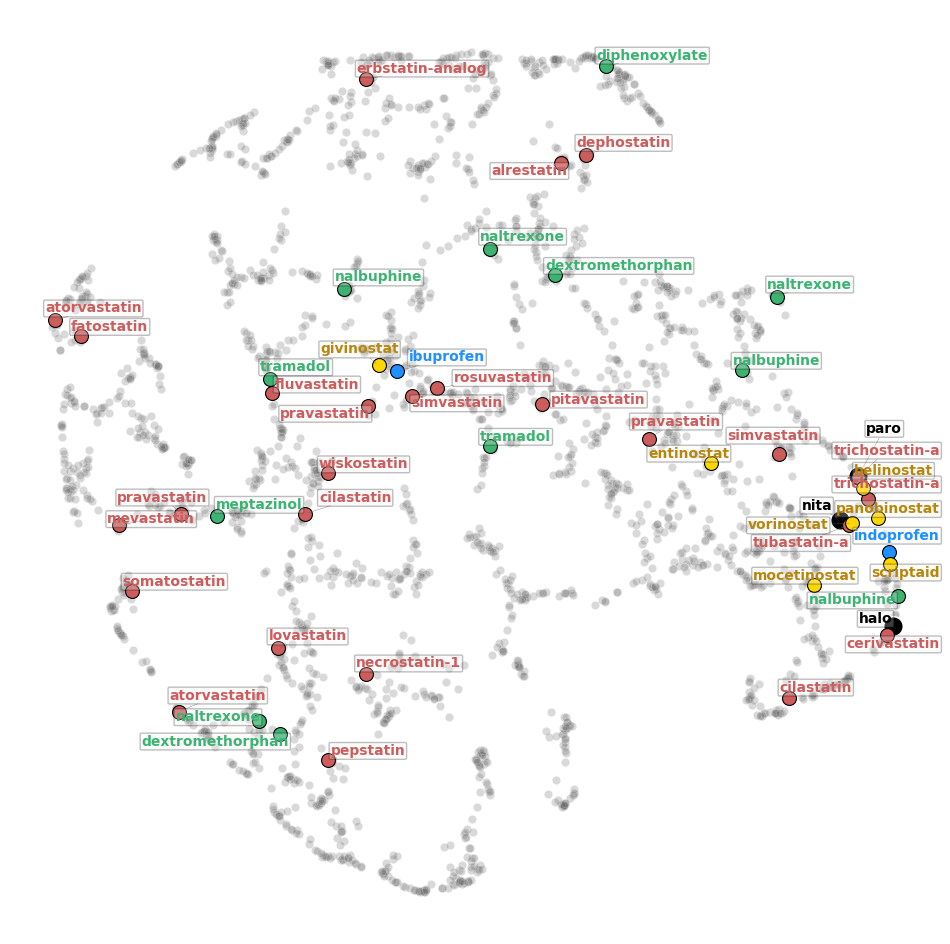

In [ ]:
from adjustText import adjust_text

# Define treatment list
list_treat = ['halo', 'nita', 'paro'] 

# Plot
plt.figure(figsize = (12,12))
sns.scatterplot(df_plot, x = 'x', y = 'y', color = 'dimgrey', alpha = 0.25)
sns.scatterplot(df_plot[df_plot['perturbagen_name'].isin(list_treat)], x = 'x', y = 'y', color = 'black', s = 200)
sns.scatterplot(df_plot[df_plot['perturbagen_name'].str.contains('statin')], x = 'x', y = 'y', color = 'indianred', s = 100, edgecolor = 'black')
sns.scatterplot(df_plot[df_plot['perturbagen_name'].isin(list_opioid)], x = 'x', y = 'y', color = 'mediumseagreen', s = 100, edgecolor = 'black')
sns.scatterplot(df_plot[df_plot['perturbagen_name'].isin(list_profen)], x = 'x', y = 'y', color = 'dodgerblue', s = 100, edgecolor = 'black')
sns.scatterplot(df_plot[df_plot['perturbagen_name'].isin(list_hdac)], x = 'x', y = 'y', color = 'gold', s = 100, edgecolor = 'black')

list_text = []
seen_points = set()   # prevent exact duplicates only

for idx, row in df_plot.iterrows():
    drug = row['perturbagen_name']
    x, y = row['x'], row['y']

    # Skip points that are not in any category
    if (
        drug not in list_treat and
        drug not in list_statin and
        drug not in list_opioid and
        drug not in list_profen and
        drug not in list_hdac
    ):
        continue

    # Prevent duplicate label if exact same coordinate/name repeats
    key = (drug, x, y)
    if key in seen_points:
        continue
    seen_points.add(key)

    # Color logic
    if drug in list_treat:
        label_color = 'black'
    elif drug in list_statin:
        label_color = 'indianred'
    elif drug in list_opioid:
        label_color = 'mediumseagreen'
    elif drug in list_profen:
        label_color = 'dodgerblue'
    elif drug in list_hdac:
        label_color = 'darkgoldenrod'
    else:
        label_color = 'black'

    # Label style
    label_style = {
        'fontsize': 10,
        'alpha': 1,
        'weight': 'bold',
        'color': label_color,
        'ha': 'center',
        'va': 'bottom',
        'bbox': {
            'facecolor': 'whitesmoke',
            'alpha': 0.25,
            'edgecolor': 'black',
            'boxstyle': 'round, pad=0.1'
        }
    }

    list_text.append(
        plt.text(x, y, drug, **label_style)
    )

# Adjust text positions
adjust_text(list_text, arrowprops=dict(arrowstyle='-', color='dimgrey', lw=0.25))

# # Initialise treatment text label list
# treated_text = []

# # Iterate through treatments
# for treatment in list_treat:
#     # Slice
#     df_slice = df_plot[df_plot['perturbagen_name'] == treatment]
#     # Get coordinates
#     x, y = df_slice['x'].values[0], df_slice['y'].values[0]
#     # Get label
#     label = df_slice['perturbagen_name'].values[0]

#     # Label styling
#     label_style = {'fontsize' : 10, 'alpha' : 1, 'weight' : 'bold', 'color' : 'black',
#                    'bbox' : {'facecolor': 'whitesmoke', 'alpha' : 0.25, 'edgecolor' : 'black', 'boxstyle' : 'round, pad = 0.1'}}
    
#     # Append with styling
#     treated_text.append(plt.text(x, y, label, **label_style))

# # Initialise statin list
# statin_text = []

# # Iterate through statins
# for statin in pd.unique(df_statin['perturbagen_name']):
#     # Slice
#     df_slice = df_plot[df_plot['perturbagen_name'] == statin]
#     # Get coordinates
#     x, y = df_slice['x'].values[0], df_slice['y'].values[0]
#     # Get label
#     label = df_slice['perturbagen_name'].values[0]

#     # Label styling
#     label_style = {'fontsize' : 10, 'alpha' : 1, 'weight' : 'bold', 'color' : 'indianred',
#                    'bbox' : {'facecolor': 'whitesmoke', 'alpha' : 0.25, 'edgecolor' : 'black', 'boxstyle' : 'round, pad = 0.1'}}
    
#     # Append with styling
#     statin_text.append(plt.text(x, y, label, **label_style))

# # Initialise opioid list
# opioid_text = []

# # Iterate through opioids
# for opioid in list_opioid:
#     # Slice
#     df_slice = df_plot[df_plot['perturbagen_name'] == opioid]
#     # Get coordinates
#     x, y = df_slice['x'].values[0], df_slice['y'].values[0]
#     # Get label
#     label = df_slice['perturbagen_name'].values[0]

#     # Label styling
#     label_style = {'fontsize' : 10, 'alpha' : 1, 'weight' : 'bold', 'color' : 'mediumseagreen',
#                    'bbox' : {'facecolor': 'whitesmoke', 'alpha' : 0.25, 'edgecolor' : 'black', 'boxstyle' : 'round, pad = 0.1'}}
    
#     # Append with styling
#     opioid_text.append(plt.text(x, y, label, **label_style))

# # Iterate through HDACs
# hdac_text = []

# # Iterate through HDACs
# for hdac in list_hdac:
#     # Slice
#     df_slice = df_plot[df_plot['perturbagen_name'] == hdac]
#     # Get coordinates
#     x, y = df_slice['x'].values[0], df_slice['y'].values[0]
#     # Get label
#     label = df_slice['perturbagen_name'].values[0]

#     # Label styling
#     label_style = {'fontsize' : 10, 'alpha' : 1, 'weight' : 'bold', 'color' : 'gold',
#                    'bbox' : {'facecolor': 'whitesmoke', 'alpha' : 0.25, 'edgecolor' : 'black', 'boxstyle' : 'round, pad = 0.1'}}
    
#     # Append with styling
#     hdac_text.append(plt.text(x, y, label, **label_style))

# # Adjust text labels
# adjust_text(treated_text,
#             arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25));


plt.axis('off')

### Clustering

In [ ]:
import hdbscan
# Initialise clustering
#clusterer = hdbscan.HDBSCAN()
clusterer = hdbscan.HDBSCAN(min_cluster_size = 4)
# Get cluster labels
labels = clusterer.fit_predict(consensus_emb)

# Initialise dataframe
df_cluster = df_plot.copy()
df_cluster['cluster'] = labels

# Report number of clusters identified
num_clusters = len(pd.unique(df_cluster['cluster']))
print(f'{num_clusters} clusters identified')

# Show data
df_cluster.head()

c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\roman\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


94 clusters identified


,x,y,perturbagen_id,timepoint,dose,perturbagen_name,cluster
0,14.380774,1.699631,halo,6H,20.85,halo,12
1,13.175150,3.561789,nita,6H,15.4,nita,-1
2,13.598949,4.326806,paro,6H,9.72,paro,-1
3,-4.543064,5.490571,BRD-A00100033,6H,10,nifurtimox,-1
4,-4.456341,4.286147,BRD-A00546892,6H,10,biperiden,56


In [ ]:
# Initialise list
representatives = []

# Iterate through identified clusteres
for label, cluster in df_cluster.groupby('cluster'):
    # # Get cluster centroid
    # centroid = cluster[['x', 'y']].mean().values
    # # Calculate distances of each drug in cluster to centroid
    # distances = np.linalg.norm(cluster[['x', 'y']].values - centroid, axis=1)
    # # Get closest drug
    # closest_drug = cluster.index[np.argmin(distances)]
    # # Append to list
    # representatives.append(df_cluster.loc[closest_drug])
    # Check for labels > -1 (points designated as 'noise')
    if label > -1:
        # Get cluster centroid
        centroid = cluster[['x', 'y']].mean().values
        # Calculate distances of each drug in cluster to centroid
        distances = np.linalg.norm(cluster[['x', 'y']].values - centroid, axis=1)
        # Get closest drug
        closest_drug = cluster.index[np.argmin(distances)]
        # Append to list
        representatives.append(df_cluster.loc[closest_drug])
    
# Convert to dataframe
df_representatives = pd.DataFrame(representatives)
# Show data
df_representatives.head()

,x,y,perturbagen_id,timepoint,dose,perturbagen_name,cluster
1808,12.613149,2.714836,BRD-K64822626,6H,10,KU-C104135,0
1301,6.864317,-1.445935,BRD-K39345836,6H,10,BRD-K39345836,1
892,6.871828,-0.194515,BRD-K18249495,6H,10,BRD-K18249495,2
1380,12.792057,1.048935,BRD-K43739430,6H,10,ST-4029487,3
1457,11.967551,0.450796,BRD-K47983010,6H,10,BX-795,4


(np.float64(-5.752628803253174),
 np.float64(15.4344162940979),
 np.float64(-3.6951151847839356),
 np.float64(12.432540035247802))

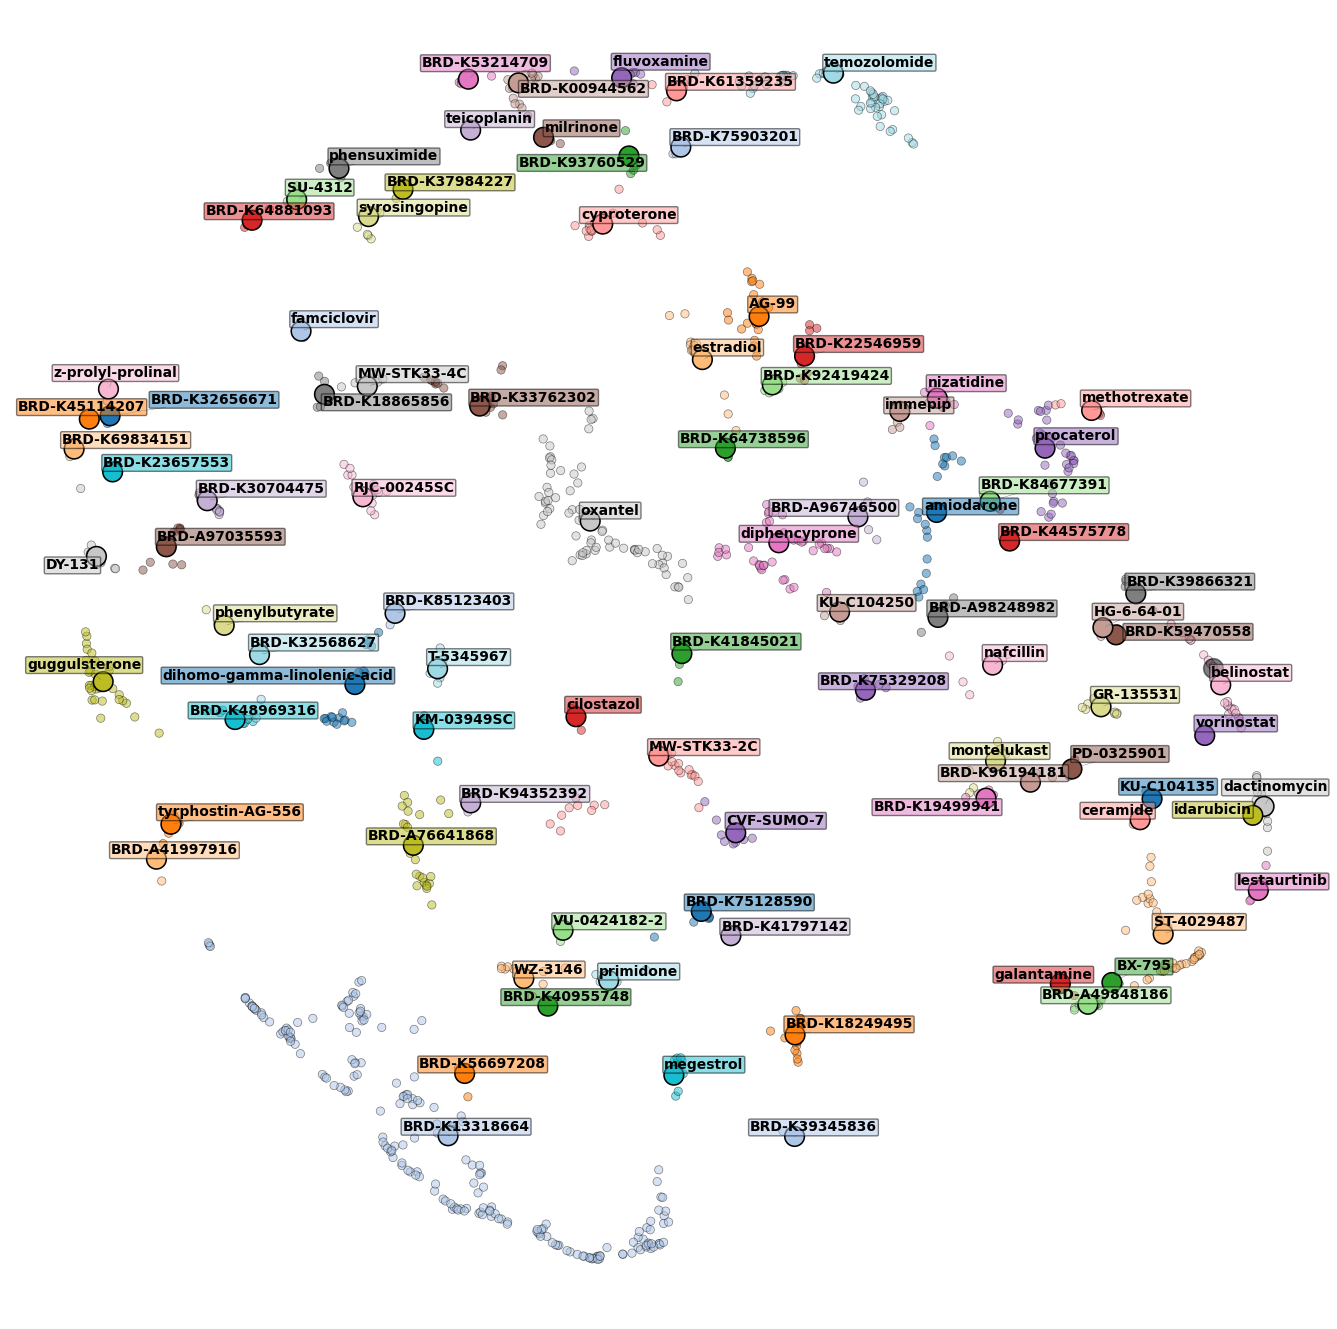

In [ ]:
plt.figure(figsize = (17,17))
sns.scatterplot(df_cluster[df_cluster['cluster'] != -1],
                x = 'x', y = 'y', hue = 'cluster', palette = 'tab20', alpha = 0.5, edgecolors = 'black',
                legend = False)
#sns.scatterplot(df_cluster[df_cluster['perturbagen_name'].isin(list_treat)],
sns.scatterplot(df_cluster[df_cluster['perturbagen_name'] == 'paro'],
                x = 'x', y = 'y', color = 'black', s = 200, edgecolors = 'black', alpha = 0.5,
                legend = False)
sns.scatterplot(df_representatives, 
                x = 'x', y = 'y', 
                hue = 'cluster', palette = 'tab20', 
                edgecolors = 'black', s = 200, legend = False)

# Initialise representative text label list
rep_texts = []
palette_colors = list(sns.color_palette('tab20', n_colors = num_clusters - 1))

# Iterate through representative drug IDs and palette colours
for id, colour in zip(pd.unique(df_representatives['perturbagen_name']), palette_colors):
    # Slice dataframe
    df_slice = df_representatives[df_representatives['perturbagen_name'] == id]
    # Get coordinates
    x, y = df_slice['x'].values[0], df_slice['y'].values[0]
    # Get label
    label = df_slice['perturbagen_name'].values[0]

    # Set label styling
    rep_style = {'fontsize': 10,
                 'alpha' : 1,
                 'weight' : 'bold',
                 'color': 'black',
                 'ha': 'center',             
                 'va': 'bottom',             
                 'bbox': {'facecolor': colour,
                          'alpha': 0.5,
                          'edgecolor': 'black',
                          'boxstyle': 'round,pad=0.1'}}

    # Append with styling
    rep_texts.append(plt.text(x, y, label, **rep_style))

# Adjust text labels
adjust_text(rep_texts,
            arrowprops=dict(arrowstyle='-', color='dimgrey', lw = 0.25));

plt.axis('off')

## Visualisations

In [ ]:
# # Define file list
# file_list = [file for file in os.listdir(RNASEQ) if '6h' in file]

# df_dist = pd.DataFrame()

# # Iterate through RNASEQ files
# for file in file_list:

#     treatment = file.split('_')[1]
    
#     # Load graph
#     graph = pickle_load(RNASEQ + file)
#     # Extract node values
#     list_values = [graph.nodes[node]['dexp'] for node in graph.nodes]
#     # Convert to dataframe
#     df = pd.DataFrame({'values' : list_values})
#     # Add column
#     df['treatment'] = treatment
#     # Concatenate data
#     df_dist = pd.concat([df_dist, df])

# # Iterate through CONTEXT files
# for file in os.listdir(CONTEXT):

#     treatment = file.split('_')[1]

#     # Load graph
#     graph = pickle_load(CONTEXT + file)
#     # Extract node values
#     list_values = [graph.nodes[node]['dexp'] for node in graph.nodes]
#     # Convert to dataframe
#     df = pd.DataFrame({'values' : list_values})
#     # Add column
#     df['treatment'] = treatment
#     # Concatenate data
#     df_dist = pd.concat([df_dist, df])

In [ ]:
# # Define treatment list
# list_treatment = ['Halo', 'Nita', 'Paro']
# # Add label column
# df_dist['label'] = ''
# # Set label values
# df_dist.loc[df_dist['treatment'] == 'Halo', 'label'] = 'Halo'
# df_dist.loc[df_dist['treatment'] == 'Nita', 'label'] = 'Nita'
# df_dist.loc[df_dist['treatment'] == 'Paro', 'label'] = 'Paro'
# df_dist.loc[~df_dist['treatment'].isin(list_treatment), 'label'] = 'LINCS'
# df_dist.head()

In [ ]:
# # Plot
# plt.figure(figsize = (10,3.33))
# plt.title('Distribution of Level 5 MODZ values')
# sns.boxplot(df_dist, x = 'values', y = 'label', hue = 'label', palette = ['dimgrey', 'dimgrey', 'dimgrey', 'dimgrey'],
#             showcaps = False, 
#             flierprops={'marker': 'x', 'alpha' : 0.5},
#             medianprops={'color': 'deepskyblue'},
#             boxprops = {'alpha' : 0.8})
# plt.ylabel('')
# plt.xlabel('Value')
# plt.axvline(x = 0, color = 'black', linewidth = 1)

In [ ]:
# # Load graph
# graph_cds = pickle_load(INPUT + 'graph_cds.pkl')
# print(len(graph_cds.nodes))
# print(len(graph_cds.edges))

# # Calculate positional data
# pos = nx.spring_layout(graph_cds, k = 0.2)

# plt.figure(figsize = (12,12))
# nx.draw_networkx_edges(graph_cds, pos = pos, edge_color = 'dimgrey', alpha = 0.5)
# nx.draw_networkx_nodes(graph_cds, pos = pos, node_size = 50, node_color = 'lightblue', edgecolors = 'black')
# plt.axis('off')